In [1]:
import pandas as pd

# Load dataset (relative path from notebooks folder)
df = pd.read_csv("../data/processed/cleaned_data.csv")

print("✅ Dataset Loaded Successfully")

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumns:")
print(df.columns)

print("\nShape:")
print(df.shape)

✅ Dataset Loaded Successfully

First 5 Rows:


,Invoice,Product_ID,Description,Quantity,Invoice_Date,Price,Customer_ID,Country,Year,Month,Day,DayOfWeek,Total_Amount,Recency,Frequency,Monetary,Churn,Segment,RFM_Score
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,1,Wednesday,15.30,372,297,5391.21,1,At Risk,144
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,Wednesday,20.34,372,297,5391.21,1,At Risk,144
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,1,Wednesday,22.00,372,297,5391.21,1,At Risk,144
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,Wednesday,20.34,372,297,5391.21,1,At Risk,144
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,Wednesday,20.34,372,297,5391.21,1,At Risk,144



Columns:
Index(['Invoice', 'Product_ID', 'Description', 'Quantity', 'Invoice_Date',
       'Price', 'Customer_ID', 'Country', 'Year', 'Month', 'Day', 'DayOfWeek',
       'Total_Amount', 'Recency', 'Frequency', 'Monetary', 'Churn', 'Segment',
       'RFM_Score'],
      dtype='object')

Shape:
(388805, 19)


In [2]:
# STEP 2 — Create Clean RFM Table

# Select required columns
rfm = df[['Customer_ID', 'Recency', 'Frequency', 'Monetary']]

# Remove duplicate customers
rfm = rfm.drop_duplicates(subset='Customer_ID')

# Set Customer_ID as index
rfm = rfm.set_index('Customer_ID')

print("✅ RFM Table Created")

print("\nFirst 5 Customers:")
display(rfm.head())

print("\nShape of RFM Table:")
print(rfm.shape)

print("\nMissing Values:")
print(rfm.isnull().sum())

✅ RFM Table Created

First 5 Customers:


,Recency,Frequency,Monetary
Customer_ID,,,
17850,372,297,5391.21
13047,32,172,3237.54
12583,3,243,7130.18
13748,96,28,948.25
15100,334,3,876.00



Shape of RFM Table:
(4303, 3)

Missing Values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [3]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale RFM data
rfm_scaled = scaler.fit_transform(rfm)

print("✅ Scaling Completed")

# Convert back to DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=rfm.columns
)

print("\nFirst 5 Scaled Rows:")
display(rfm_scaled_df.head())

print("\nShape of Scaled Data:")
print(rfm_scaled_df.shape)

✅ Scaling Completed

First 5 Scaled Rows:


,Recency,Frequency,Monetary
Customer_ID,,,
17850,2.792374,0.921539,0.736913
13047,-0.606403,0.364094,0.310143
12583,-0.896298,0.680723,1.081507
13748,0.033367,-0.278084,-0.143502
15100,2.412511,-0.389573,-0.157820



Shape of Scaled Data:
(4303, 3)


✅ WCSS calculated


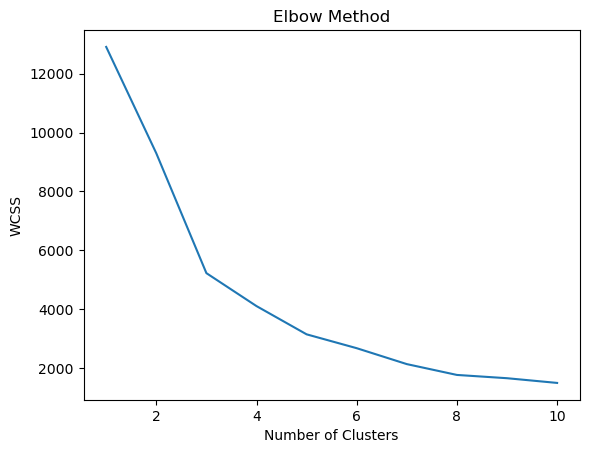

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store WCSS values
wcss = []

# Try different cluster numbers
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    kmeans.fit(rfm_scaled_df)
    
    wcss.append(kmeans.inertia_)

print("✅ WCSS calculated")

# Plot Elbow Graph
plt.figure()

plt.plot(range(1, 11), wcss)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [5]:
# STEP 5 — Apply Final K-Means

from sklearn.cluster import KMeans

# Apply KMeans with optimal K=3
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Fit model and assign clusters
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

print("✅ Clustering Completed")

print("\nCluster Counts:")
print(rfm['Cluster'].value_counts())

print("\nFirst 5 Customers with Clusters:")
display(rfm.head())

✅ Clustering Completed

Cluster Counts:
Cluster
0    3206
1    1085
2      12
Name: count, dtype: int64

First 5 Customers with Clusters:


,Recency,Frequency,Monetary,Cluster
Customer_ID,,,,
17850,372,297,5391.21,1
13047,32,172,3237.54,0
12583,3,243,7130.18,0
13748,96,28,948.25,0
15100,334,3,876.00,1


In [6]:
import numpy as np

# Apply log transformation
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

print("✅ Log Transformation Applied")

print("\nFirst 5 Rows After Log:")
display(rfm_log.head())

✅ Log Transformation Applied

First 5 Rows After Log:


,Recency,Frequency,Monetary,Cluster
Customer_ID,,,,
17850,5.921578,5.697093,8.592711,1
13047,3.496508,5.153292,8.082878,0
12583,1.386294,5.497168,8.872232,0
13748,4.574711,3.367296,6.855672,0
15100,5.814131,1.386294,6.776507,1


In [7]:
from sklearn.preprocessing import StandardScaler

# Use only RFM columns (ignore Cluster column)
rfm_log_features = rfm_log[['Recency', 'Frequency', 'Monetary']]

# Initialize scaler
scaler = StandardScaler()

# Scale log data
rfm_log_scaled = scaler.fit_transform(rfm_log_features)

# Convert to DataFrame
rfm_log_scaled_df = pd.DataFrame(
    rfm_log_scaled,
    index=rfm_log.index,
    columns=rfm_log_features.columns
)

print("✅ Log Data Scaling Completed")

print("\nFirst 5 Scaled Log Rows:")
display(rfm_log_scaled_df.head())

print("\nShape:")
print(rfm_log_scaled_df.shape)

✅ Log Data Scaling Completed

First 5 Scaled Log Rows:


,Recency,Frequency,Monetary
Customer_ID,,,
17850,1.559328,1.586375,1.661452
13047,-0.250710,1.146516,1.248641
12583,-1.825743,1.424664,1.887780
13748,0.554045,-0.298104,0.254973
15100,1.479130,-1.900457,0.190873



Shape:
(4303, 3)


In [8]:
from sklearn.cluster import KMeans

# Apply KMeans again
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42
)

# Fit and predict clusters
rfm_log['Cluster_Final'] = kmeans_final.fit_predict(rfm_log_scaled_df)

print("✅ Final Clustering Completed")

print("\nNew Cluster Counts:")
print(rfm_log['Cluster_Final'].value_counts())

print("\nFirst 5 Customers with Final Clusters:")
display(rfm_log.head())


✅ Final Clustering Completed

New Cluster Counts:
Cluster_Final
0    1819
1    1525
2     959
Name: count, dtype: int64

First 5 Customers with Final Clusters:


,Recency,Frequency,Monetary,Cluster,Cluster_Final
Customer_ID,,,,,
17850,5.921578,5.697093,8.592711,1,0
13047,3.496508,5.153292,8.082878,0,2
12583,1.386294,5.497168,8.872232,0,2
13748,4.574711,3.367296,6.855672,0,0
15100,5.814131,1.386294,6.776507,1,1


In [9]:
# STEP 9 — Analyze Cluster Behavior

cluster_summary = rfm_log.groupby('Cluster_Final').mean()

print("✅ Cluster Summary Created")

display(cluster_summary)


✅ Cluster Summary Created


,Recency,Frequency,Monetary,Cluster
Cluster_Final,,,,
0,3.761122,3.951886,6.696412,0.112150
1,4.866610,2.538676,5.392812,0.577705
2,2.323027,5.229801,8.071050,0.025026


In [10]:
# STEP 10 — Assign Segment Names

segment_map = {
    2: "High Value",
    0: "Regular",
    1: "At Risk"
}

rfm_log['Segment'] = rfm_log['Cluster_Final'].map(segment_map)

print("✅ Segment Names Assigned")

print("\nSegment Counts:")
print(rfm_log['Segment'].value_counts())

print("\nFirst 5 Customers with Segment:")
display(rfm_log.head())

✅ Segment Names Assigned

Segment Counts:
Segment
Regular       1819
At Risk       1525
High Value     959
Name: count, dtype: int64

First 5 Customers with Segment:


,Recency,Frequency,Monetary,Cluster,Cluster_Final,Segment
Customer_ID,,,,,,
17850,5.921578,5.697093,8.592711,1,0,Regular
13047,3.496508,5.153292,8.082878,0,2,High Value
12583,1.386294,5.497168,8.872232,0,2,High Value
13748,4.574711,3.367296,6.855672,0,0,Regular
15100,5.814131,1.386294,6.776507,1,1,At Risk


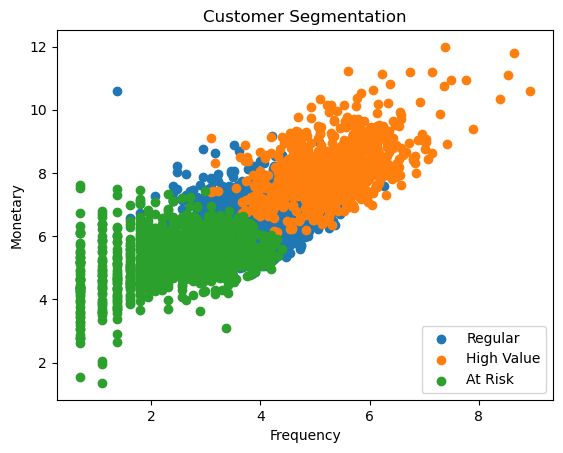

✅ Segmentation Graph Created & Saved


In [11]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure()

for segment in rfm_log['Segment'].unique():
    
    subset = rfm_log[rfm_log['Segment'] == segment]
    
    plt.scatter(
        subset['Frequency'],
        subset['Monetary'],
        label=segment
    )

plt.title("Customer Segmentation")

plt.xlabel("Frequency")

plt.ylabel("Monetary")

plt.legend()

# Save visualization
plt.savefig("../visuals/customer_segmentation.png")

plt.show()

print("✅ Segmentation Graph Created & Saved")

In [12]:
# STEP 12 — Save Final Dataset

# Select final columns
final_segments = rfm_log[[
    'Recency',
    'Frequency',
    'Monetary',
    'Segment'
]]

# Reset index to include Customer_ID
final_segments = final_segments.reset_index()

# Save file
final_segments.to_csv(
    "../data/output/customer_segments.csv",
    index=False
)

print("✅ customer_segments.csv saved successfully")

✅ customer_segments.csv saved successfully


In [13]:
import pickle

# STEP 13 — Save KMeans Model

model_path = "../models/segmentation_model.pkl"

# Save model
with open(model_path, "wb") as file:
    pickle.dump(kmeans_final, file)

print("✅ segmentation_model.pkl saved successfully")

✅ segmentation_model.pkl saved successfully


In [14]:
# STEP 14 — Generate Business Insights

segment_summary = final_segments.groupby('Segment').agg({
    'Customer_ID': 'count',
    'Frequency': 'mean',
    'Monetary': 'mean'
})

# Rename column
segment_summary = segment_summary.rename(
    columns={'Customer_ID': 'Customer_Count'}
)

print("✅ Segment Business Summary Created")

display(segment_summary)


✅ Segment Business Summary Created


,Customer_Count,Frequency,Monetary
Segment,,,
At Risk,1525,2.538676,5.392812
High Value,959,5.229801,8.071050
Regular,1819,3.951886,6.696412
